# Part B: Model Training & Cross-Validation

In [12]:
import warnings
warnings.filterwarnings("ignore")

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.model_selection import cross_validate, StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

### Define Baseline Models

In [13]:
# linear baseline, nonlinear single tree, ensemble trees, kernel method, boosted trees
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),  # 100 trees (arbitrary)
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),  # radial basis function kernel
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),  # multiclass log loss
}

### 5-Fold Cross-Validation (Baselines)

In [14]:
# stratified keeps class ratios consistent across folds since enrolled is only 18% of the data
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

cv_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    cv_results.append({
        "Model": name,
        "Accuracy": str(scores['test_accuracy'].mean()) + " +/- " + str(scores['test_accuracy'].std()),
        "Precision": str(scores['test_precision_macro'].mean()) + " +/- " + str(scores['test_precision_macro'].std()),
        "Recall": str(scores['test_recall_macro'].mean()) + " +/- " + str(scores['test_recall_macro'].std()),
        "F1 macro": str(scores['test_f1_macro'].mean()) + " +/- " + str(scores['test_f1_macro'].std()),
    })
    print("done:", name)

cv_df = pd.DataFrame(cv_results)
display(cv_df)

done: Logistic Regression
done: Decision Tree
done: Random Forest
done: SVM (RBF)
done: XGBoost


,Model,Accuracy,Precision,Recall,F1 macro
0,Logistic Regression,0.7660277771118517 +/- 0.013945299932083736,0.7077469358846932 +/- 0.02818972432588721,0.668110173743903 +/- 0.016200919842094326,0.6755922066839094 +/- 0.019245267733565108
1,Decision Tree,0.6832426341907798 +/- 0.009080954142522203,0.624317107703735 +/- 0.006629685960795417,0.625278540538446 +/- 0.008898526499187846,0.624000063168338 +/- 0.007550121141171746
2,Random Forest,0.7716882826297158 +/- 0.012371960697186359,0.7221911292308516 +/- 0.019896456568085,0.679678713212935 +/- 0.022408488450672767,0.6888802096836427 +/- 0.02527544401377576
3,SVM (RBF),0.7584058526918066 +/- 0.007216779171435001,0.7092967089414468 +/- 0.014249355989994153,0.6602316770244908 +/- 0.01036379712644185,0.6710685513996832 +/- 0.012664971998783157
4,XGBoost,0.772533742478364 +/- 0.009261159090320041,0.7227581940796257 +/- 0.010612078704784108,0.6954524419630638 +/- 0.010909738048618684,0.7039205115728364 +/- 0.010726302362580376


### Overfitting / Underfitting Analysis (Train vs CV Score)

,Model,Train F1,CV F1,Gap,Diagnosis
0,Logistic Regression,0.6913,0.6756,0.0157,Good fit
1,Decision Tree,1.0000,0.6240,0.3760,Overfitting
2,Random Forest,1.0000,0.6889,0.3111,Overfitting
3,SVM (RBF),0.7727,0.6711,0.1016,Overfitting
4,XGBoost,1.0000,0.7039,0.2961,Overfitting


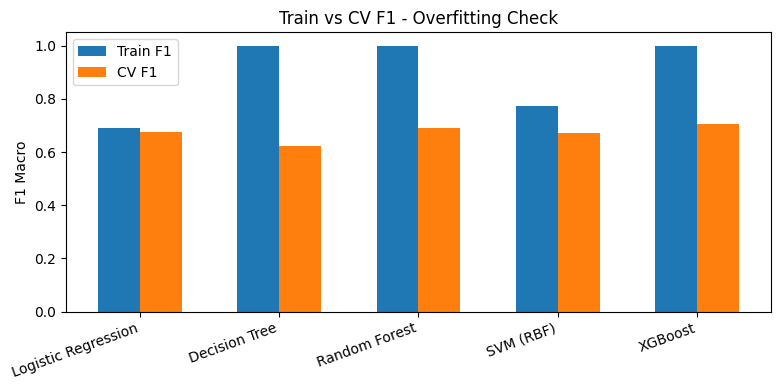

In [15]:
# compare train score vs cv score to detect overfitting or underfitting
overfit_results = []

for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", return_train_score=True)
    train_mean = scores['train_score'].mean()
    test_mean = scores['test_score'].mean()
    gap = train_mean - test_mean
    overfit_results.append({
        "Model": name,
        "Train F1": round(train_mean, 4),
        "CV F1": round(test_mean, 4),
        "Gap": round(gap, 4),
        "Diagnosis": "Overfitting" if gap > 0.05 else ("Underfitting" if test_mean < 0.65 else "Good fit")
    })

overfit_df = pd.DataFrame(overfit_results)
display(overfit_df)

# visualize the gap
fig, ax = plt.subplots(figsize=(8, 4))
x = range(len(overfit_df))
ax.bar([i - 0.15 for i in x], overfit_df["Train F1"], width=0.3, label="Train F1")
ax.bar([i + 0.15 for i in x], overfit_df["CV F1"], width=0.3, label="CV F1")
ax.set_xticks(list(x))
ax.set_xticklabels(overfit_df["Model"], rotation=20, ha="right")
ax.set_ylabel("F1 Macro")
ax.set_title("Train vs CV F1 - Overfitting Check")
ax.legend()
plt.tight_layout()
plt.show()

### Hyperparameter Tuning - Logistic Regression

In [16]:
lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],  # smaller C = stronger regularization
    "penalty": ["l1", "l2"],  # l1 can zero out features (absolute), l2 just shrinks them (square)
    "solver": ["saga"], 
}

lr_grid = GridSearchCV(
    LogisticRegression(max_iter=2000, random_state=42),
    lr_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,  
    refit=True 
)
lr_grid.fit(X_train, y_train)

print("Best params:", lr_grid.best_params_)
print("Best CV F1:", lr_grid.best_score_)

# show top 5 configs sorted by F1
lr_top5 = (
    pd.DataFrame(lr_grid.cv_results_)
    [["param_C", "param_penalty", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
lr_top5.columns = ["C", "Penalty", "Mean F1", "Std F1"]
display(lr_top5)

Best params: {'C': 1, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1: 0.6762159037554972


,C,Penalty,Mean F1,Std F1
0,1.0,l1,0.676216,0.016886
1,1.0,l2,0.675680,0.019243
2,10.0,l2,0.675499,0.016951
3,100.0,l2,0.675499,0.016951
4,10.0,l1,0.675079,0.016477


### Hyperparameter Tuning - SVM (RBF)

In [17]:
svm_param_grid = {
    "C": [0.1, 1, 10, 100],  # tradeoff between margin width and misclassification
    "gamma": ["scale", "auto", 0.01, 0.1],  # high gamma = tighter decision boundary, risk overfitting
}

svm_grid = GridSearchCV(
    SVC(kernel="rbf", random_state=42),
    svm_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
svm_grid.fit(X_train, y_train)

print("Best params:", svm_grid.best_params_)
print("Best CV F1:", svm_grid.best_score_)

svm_top5 = (
    pd.DataFrame(svm_grid.cv_results_)
    [["param_C", "param_gamma", "mean_test_score", "std_test_score"]]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .reset_index(drop=True)
)
svm_top5.columns = ["C", "Gamma", "Mean F1", "Std F1"]
display(svm_top5)

Best params: {'C': 10, 'gamma': 0.01}
Best CV F1: 0.6821291320290029


,C,Gamma,Mean F1,Std F1
0,10.0,0.01,0.682129,0.025208
1,10.0,scale,0.674944,0.019151
2,1.0,0.01,0.674700,0.008176
3,10.0,auto,0.672852,0.019489
4,1.0,scale,0.671069,0.012665


### Hyperparameter Tuning - Random Forest

In [18]:
rf_param_grid = {
    "n_estimators": [50, 100, 200],  # number of trees
    "max_depth": [None, 10, 20],  # None = grow until pure leaves
    "min_samples_split": [2, 5],  # min samples to split a node
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
rf_grid.fit(X_train, y_train)

print("Best params:", rf_grid.best_params_)
print("Best CV F1:", rf_grid.best_score_)

Best params: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.6925286665349987


### Hyperparameter Tuning - XGBoost

In [19]:
xgb_param_grid = {
    "n_estimators": [100, 200],  # boosting rounds
    "max_depth": [3, 5, 7],  # deeper = more complex, risk overfitting
    "learning_rate": [0.01, 0.1, 0.3],  # step size shrinkage
}

xgb_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    xgb_param_grid,
    cv=cv,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True
)
xgb_grid.fit(X_train, y_train)

print("Best params:", xgb_grid.best_params_)
print("Best CV F1:", xgb_grid.best_score_)

/Users/haoyang/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [00:06:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/haoyang/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [00:06:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/haoyang/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [00:06:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/haoyang/Library/Python/3.9/lib/python/site-packages/xgboost/core.py:158: UserWarning: [00:06:06] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn

Best params: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
Best CV F1: 0.7134780754323927


### Ablation Study - 10+ Configurations

done: XGB default
done: XGB depth=3
done: XGB depth=7
done: XGB depth=10
done: XGB lr=0.01
done: XGB lr=0.3
done: XGB n_est=50
done: XGB n_est=300
done: LR balanced
done: RF balanced
done: SVM balanced
done: DT balanced


,Config,Train F1,CV F1,Std
0,XGB depth=3,0.8745,0.7135,0.0069
1,XGB n_est=300,1.0000,0.7068,0.0145
2,XGB n_est=50,0.9880,0.7057,0.0088
3,XGB default,1.0000,0.7039,0.0107
4,XGB lr=0.3,1.0000,0.7039,0.0107
5,LR balanced,0.7225,0.7036,0.0116
6,XGB depth=7,1.0000,0.7031,0.0157
7,XGB depth=10,1.0000,0.6990,0.0103
8,SVM balanced,0.7931,0.6938,0.0128
9,RF balanced,1.0000,0.6856,0.0135


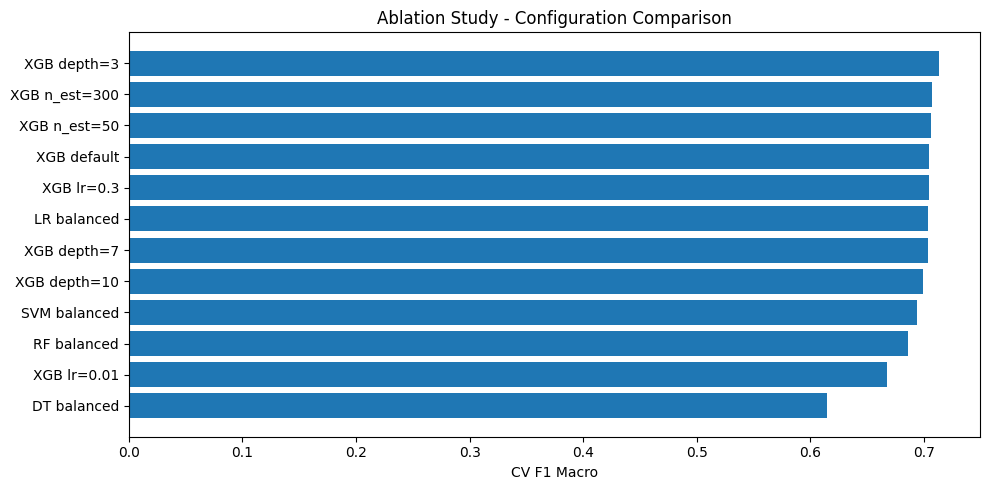

In [20]:
# systematically testing one thing at a time to measure impact
ablation_configs = {
    # baseline
    "XGB default": XGBClassifier(use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary max_depth
    "XGB depth=3": XGBClassifier(max_depth=3, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB depth=7": XGBClassifier(max_depth=7, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB depth=10": XGBClassifier(max_depth=10, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary learning rate
    "XGB lr=0.01": XGBClassifier(learning_rate=0.01, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB lr=0.3": XGBClassifier(learning_rate=0.3, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # vary n_estimators
    "XGB n_est=50": XGBClassifier(n_estimators=50, use_label_encoder=False, eval_metric="mlogloss", random_state=42),
    "XGB n_est=300": XGBClassifier(n_estimators=300, use_label_encoder=False, eval_metric="mlogloss", random_state=42),

    # class weight via scale_pos_weight approximation using sample_weight in CV isn't clean,
    # so compare balanced variants of other models instead
    "LR balanced": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "RF balanced": RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42),
    "SVM balanced": SVC(kernel="rbf", class_weight="balanced", random_state=42),
    "DT balanced": DecisionTreeClassifier(class_weight="balanced", random_state=42),
}

ablation_results = []

for name, model in ablation_configs.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring="f1_macro", return_train_score=True)
    ablation_results.append({
        "Config": name,
        "Train F1": round(scores["train_score"].mean(), 4),
        "CV F1": round(scores["test_score"].mean(), 4),
        "Std": round(scores["test_score"].std(), 4),
    })
    print("done:", name)

ablation_df = pd.DataFrame(ablation_results).sort_values("CV F1", ascending=False).reset_index(drop=True)
display(ablation_df)

# bar chart of ablation results
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(ablation_df["Config"], ablation_df["CV F1"])
ax.set_xlabel("CV F1 Macro")
ax.set_title("Ablation Study - Configuration Comparison")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Final CV Comparison (Tuned Models Swapped In)

In [21]:
# replace all models with their best tuned versions
final_models = {
    "Logistic Regression (tuned)": lr_grid.best_estimator_,
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest (tuned)": rf_grid.best_estimator_,
    "SVM RBF (tuned)": svm_grid.best_estimator_,
    "XGBoost (tuned)": xgb_grid.best_estimator_,
}

final_cv = []
for name, model in final_models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, return_train_score=False)
    final_cv.append({
        "Model": name,
        "Accuracy": str(scores['test_accuracy'].mean()) + " +/- " + str(scores['test_accuracy'].std()),
        "Precision": str(scores['test_precision_macro'].mean()) + " +/- " + str(scores['test_precision_macro'].std()),
        "Recall": str(scores['test_recall_macro'].mean()) + " +/- " + str(scores['test_recall_macro'].std()),
        "F1 macro": str(scores['test_f1_macro'].mean()) + " +/- " + str(scores['test_f1_macro'].std()),
    })

display(pd.DataFrame(final_cv))

,Model,Accuracy,Precision,Recall,F1 macro
0,Logistic Regression (tuned),0.7660289757789339 +/- 0.012013068142844686,0.7074015700658117 +/- 0.023951827198160275,0.668679320932351 +/- 0.014176335655974015,0.6762159037554972 +/- 0.016886497189948408
1,Decision Tree,0.6832426341907798 +/- 0.009080954142522203,0.624317107703735 +/- 0.006629685960795417,0.625278540538446 +/- 0.008898526499187846,0.624000063168338 +/- 0.007550121141171746
2,Random Forest (tuned),0.7742298563996834 +/- 0.01120959154428987,0.7295695618427153 +/- 0.017274355711325882,0.6819405118559019 +/- 0.017717589348859364,0.6925286665349987 +/- 0.01993068914703562
3,SVM RBF (tuned),0.761512398213187 +/- 0.016047186998925822,0.7031105345345458 +/- 0.025273791704949897,0.6742710029700398 +/- 0.022340954892097566,0.6821291320290029 +/- 0.025208414753520026
4,XGBoost (tuned),0.7841176611607892 +/- 0.006161953354631595,0.7364559174793073 +/- 0.009304454013140307,0.7040355728275653 +/- 0.0062028280125688865,0.7134780754323927 +/- 0.00693484712603341


### Test Set Evaluation

Logistic Regression (tuned)
Accuracy: 0.7694915254237288
F1: 0.68493665228397
              precision    recall  f1-score   support

     Dropout       0.79      0.77      0.78       284
    Enrolled       0.53      0.34      0.41       159
    Graduate       0.81      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.68       885
weighted avg       0.75      0.77      0.75       885



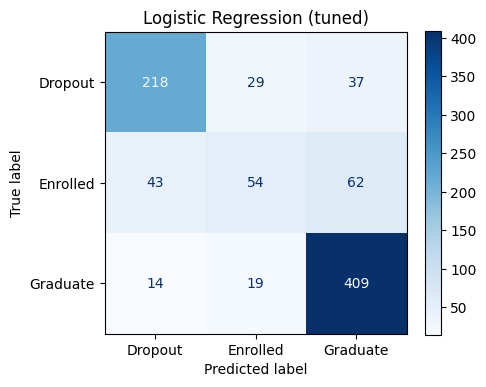


Decision Tree
Accuracy: 0.6949152542372882
F1: 0.636488781621525
              precision    recall  f1-score   support

     Dropout       0.70      0.69      0.70       284
    Enrolled       0.40      0.43      0.41       159
    Graduate       0.81      0.79      0.80       442

    accuracy                           0.69       885
   macro avg       0.64      0.64      0.64       885
weighted avg       0.70      0.69      0.70       885



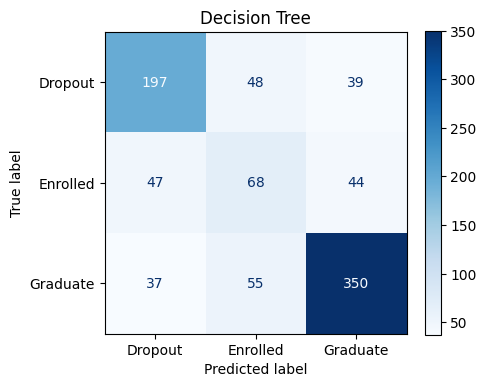


Random Forest (tuned)
Accuracy: 0.7740112994350282
F1: 0.6949358187041496
              precision    recall  f1-score   support

     Dropout       0.82      0.77      0.79       284
    Enrolled       0.56      0.36      0.44       159
    Graduate       0.79      0.93      0.86       442

    accuracy                           0.77       885
   macro avg       0.72      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



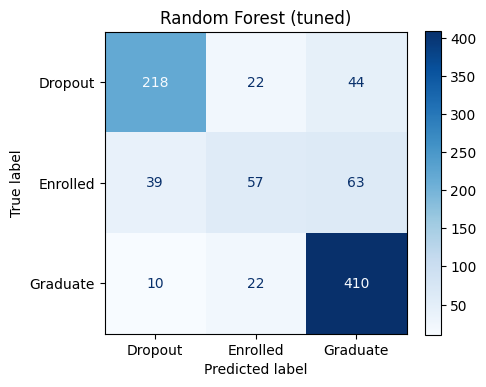

In [ ]:
# only touch test set after all model selection is done
for name, model in final_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print(name)
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1:", f1_score(y_test, y_pred, average="macro"))
    print(classification_report(y_test, y_pred, target_names=["Dropout", "Enrolled", "Graduate"])) # per-class breakdown

    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=["Dropout", "Enrolled", "Graduate"],
        cmap="Blues", ax=ax
    )
    ax.set_title(name)
    plt.tight_layout()
    plt.show()
    print()

### Error Analysis - Examining Misclassified Samples

In [ ]:
best_model = xgb_grid.best_estimator_
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

feature_names = df.drop("Target", axis=1).columns.tolist()

# build dataframe of test set with predictions
error_df = pd.DataFrame(X_test, columns=feature_names)
error_df["True Label"] = y_test.values
error_df["Predicted"] = y_pred_best
error_df["Correct"] = error_df["True Label"] == error_df["Predicted"]

# map labels back to names
label_map = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
error_df["True Name"] = error_df["True Label"].map(label_map)
error_df["Pred Name"] = error_df["Predicted"].map(label_map)

total = len(error_df)
misclassified = error_df[~error_df["Correct"]]
print("Total test samples:", total)
print("Misclassified:", len(misclassified))
print("Error rate:", round(len(misclassified) / total, 4))

In [ ]:
confusion_pairs = misclassified.groupby(["True Name", "Pred Name"]).size().reset_index(name="Count")
confusion_pairs = confusion_pairs.sort_values("Count", ascending=False).reset_index(drop=True)
print("Most common misclassification pairs:")
display(confusion_pairs)

In [ ]:
print("Feature comparison: correct vs misclassified Enrolled students")
print("(features shown are scaled values)")
print()

enrolled_correct = error_df[(error_df["True Name"] == "Enrolled") & (error_df["Correct"])]
enrolled_wrong = error_df[(error_df["True Name"] == "Enrolled") & (~error_df["Correct"])]

if len(enrolled_correct) > 0 and len(enrolled_wrong) > 0:
    comparison = pd.DataFrame({
        "Correct (mean)": enrolled_correct[feature_names].mean(),
        "Misclassified (mean)": enrolled_wrong[feature_names].mean(),
        "Difference": enrolled_wrong[feature_names].mean() - enrolled_correct[feature_names].mean()
    })
    comparison = comparison.reindex(comparison["Difference"].abs().sort_values(ascending=False).index)
    display(comparison.head(10))

In [ ]:
# where do misclassified Enrolled students actually get sent?
print("Enrolled students misclassified as:")
enrolled_errors = misclassified[misclassified["True Name"] == "Enrolled"]
print(enrolled_errors["Pred Name"].value_counts())
print()

print("Dropout students misclassified as:")
dropout_errors = misclassified[misclassified["True Name"] == "Dropout"]
print(dropout_errors["Pred Name"].value_counts())

In [ ]:
# feature importance from XGBoost, importance plots, and tabular importance values for top features
importances = best_model.feature_importances_
feat_imp = pd.DataFrame({"Feature": feature_names, "Importance": importances})
feat_imp = feat_imp.sort_values("Importance", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(8, 8))
ax.barh(feat_imp["Feature"][:15], feat_imp["Importance"][:15])
ax.set_xlabel("Importance")
ax.set_title("XGBoost Top 15 Feature Importances")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

display(feat_imp.head(15))

### Best Hyperparameters Summary

In [ ]:
print("Logistic Regression:", lr_grid.best_params_)
print("SVM RBF:", svm_grid.best_params_)
print("Random Forest:", rf_grid.best_params_)
print("XGBoost:", xgb_grid.best_params_)
print("Decision Tree: default params")